# Laboratorio 4 — Cuaderno 1: obtención de los datos

**Ejercicios 1 y 2.** Conexión con el API de Sentinel-2 y descarga de los datos raster
necesarios para analizar los lagos de Atitlán y Amatitlán.

La idea de este cuaderno es sencilla: en lugar de bajar imágenes satelitales completas
—que pesan más de un gigabyte cada una— le pedimos al servidor de Copernicus que recorte
exactamente el pedazo de mundo que nos interesa y que nos mande solo las bandas de luz
que hacen falta para los tres índices del laboratorio. Todo lo demás se queda en la nube.

## 1. Conexión con el API de Sentinel-2

Usamos el módulo `openeo`, que habla con el backend del **Copernicus Data Space Ecosystem**.
Este es el mismo servicio detrás de Copernicus Browser, pero accedido por programa.

La autenticación es un *flujo de código de dispositivo*: la primera vez el programa imprime
una dirección web y un código corto; uno abre esa dirección, inicia sesión con su cuenta de
Copernicus y confirma el código. A partir de ahí `openeo` guarda un token de refresco en el
computador y las corridas siguientes ya no piden nada.

In [1]:
import sys
from pathlib import Path

# El código compartido del laboratorio vive en Lab4/src/
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import openeo
import pandas as pd

from src import config
from src import descarga

print("openeo", openeo.client_version())
print("backend:", config.URL_OPENEO)

openeo 0.51.0
backend: https://openeo.dataspace.copernicus.eu


In [2]:
conexion = openeo.connect(config.URL_OPENEO)
conexion.authenticate_oidc()
conexion

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

### Qué producto usamos, y por qué L1C y no L2A

Sentinel-2 se publica en dos niveles. **L1C** es la reflectancia medida en el tope de la
atmósfera, tal como llega al sensor. **L2A** es esa misma imagen después de quitarle
computacionalmente el efecto de la atmósfera, para dejar la reflectancia de la superficie.

Para casi cualquier análisis L2A es la mejor opción, y es la que usa el cuaderno de ejemplo del
curso. **Aquí usamos L1C, y la razón vale la pena explicarla**, porque es un resultado del
propio laboratorio.

El script de cianobacteria que pide el enunciado se publicó para L1C —lo dice su nombre,
`cyanobacteria_chla_ndci_l1c`— y su polinomio está calibrado sobre reflectancia de tope de
atmósfera. Probamos primero con L2A y el índice se rompe sobre agua muy clara. El motivo es
que el índice divide la diferencia entre dos bandas por su suma, y sobre el agua limpísima de
Atitlán la corrección atmosférica deja esas dos bandas prácticamente en cero:

| Sobre el agua de Atitlán | L2A | L1C |
|---|---|---|
| Reflectancia mediana en el rojo (B04) | 0.0001 | 0.0213 |
| Reflectancia mediana en el borde rojo (B05) | **−0.0004** (negativa) | 0.0178 |
| Denominador del índice, mínimo | −0.059 | 0.029 |
| Píxeles con denominador casi nulo | 171,873 de 307,940 | **0** |
| Rango del NDCI resultante | −83 a +55 | −0.39 a +0.38 |

El rango teórico del NDCI es −1 a 1. Con L2A se salía por completo, porque estaba dividiendo
ruido entre ruido. Con L1C la reflectancia incluye la luz que dispersa la atmósfera, se mantiene
holgadamente positiva, y el cociente vuelve a significar algo.

La contrapartida es que L1C no trae la capa de clasificación de escena que marca las nubes. A
cambio sí trae la banda **B10**, exclusiva de L1C, que sirve justamente para detectar nube alta.

In [3]:
coleccion = conexion.describe_collection(config.COLECCION)

print("Colección :", coleccion["id"])
print("Título    :", coleccion.get("title", ""))

bandas_disponibles = coleccion["cube:dimensions"]["bands"]["values"]
print(f"\nBandas disponibles ({len(bandas_disponibles)}):")
print(", ".join(bandas_disponibles))

extension = coleccion["extent"]["temporal"]["interval"][0]
print("\nCobertura temporal desde:", extension[0])

Colección : SENTINEL2_L1C
Título    : Sentinel-2 L1C

Bandas disponibles (17):
B01, B02, B03, B04, B05, B06, B07, B08, B8A, B09, B10, B11, B12, sunAzimuthAngles, sunZenithAngles, viewAzimuthMean, viewZenithMean

Cobertura temporal desde: 2015-06-27T10:25:31Z


## 2. Área de interés y fechas

### 2.1 Los dos lagos

El enunciado nos da un rectángulo de coordenadas por lago, y los mismos rectángulos vienen
en los archivos GeoJSON. Verificamos que coincidan antes de usarlos.

In [4]:
import json

for lago in ["Atitlan", "Amatitlan"]:
    ruta = config.GEOJSON / f"Lago_{lago}.geojson"
    with open(ruta) as f:
        gj = json.load(f)

    coords = gj["features"][0]["geometry"]["coordinates"][0]
    lons = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    del_geojson = {
        "west": min(lons), "east": max(lons),
        "south": min(lats), "north": max(lats),
    }
    del_enunciado = config.AREAS[lago]

    coincide = all(
        abs(del_geojson[k] - del_enunciado[k]) < 1e-9 for k in del_enunciado
    )
    print(f"{config.NOMBRE_LARGO[lago]}")
    print(f"   enunciado: {del_enunciado}")
    print(f"   geojson  : {del_geojson}")
    print(f"   coinciden: {coincide}\n")

Lago de Atitlán
   enunciado: {'west': -91.326256, 'east': -91.07151, 'south': 14.5948, 'north': 14.750979}
   geojson  : {'west': -91.326256, 'east': -91.07151, 'south': 14.5948, 'north': 14.750979}
   coinciden: True

Lago de Amatitlán
   enunciado: {'west': -90.638065, 'east': -90.512924, 'south': 14.412347, 'north': 14.493799}
   geojson  : {'west': -90.638065, 'east': -90.512924, 'south': 14.412347, 'north': 14.493799}
   coinciden: True



### 2.2 Tamaño real de cada recorte

Conviene saber cuánta superficie estamos pidiendo, porque de eso depende el peso de la descarga.

In [5]:
import math

filas = []
for lago, area in config.AREAS.items():
    lat_media = (area["north"] + area["south"]) / 2
    # Un grado de latitud son ~111.32 km; el de longitud se encoge con el coseno de la latitud.
    alto_km = (area["north"] - area["south"]) * 111.32
    ancho_km = (area["east"] - area["west"]) * 111.32 * math.cos(math.radians(lat_media))
    filas.append({
        "lago": config.NOMBRE_LARGO[lago],
        "ancho_km": round(ancho_km, 1),
        "alto_km": round(alto_km, 1),
        "area_km2": round(ancho_km * alto_km, 1),
        "px_ancho_20m": int(ancho_km * 1000 / config.RESOLUCION_M),
        "px_alto_20m": int(alto_km * 1000 / config.RESOLUCION_M),
    })

pd.DataFrame(filas)

,lago,ancho_km,alto_km,area_km2,px_ancho_20m,px_alto_20m
0,Lago de Atitlán,27.4,17.4,477.0,1371,869
1,Lago de Amatitlán,13.5,9.1,122.3,674,453


### 2.3 Ubicación de los dos recortes

Un mapa rápido para ver dónde caen. Atitlán está en el altiplano occidental, dentro de una
caldera volcánica; Amatitlán está justo al sur de la ciudad de Guatemala.

In [6]:
import folium

mapa = folium.Map(location=[14.58, -90.95], zoom_start=9, tiles="OpenStreetMap")

for lago, area in config.AREAS.items():
    folium.Rectangle(
        bounds=[[area["south"], area["west"]], [area["north"], area["east"]]],
        color="#c1272d", weight=2, fill=True, fill_opacity=0.12,
        popup=config.NOMBRE_LARGO[lago],
        tooltip=config.NOMBRE_LARGO[lago],
    ).add_to(mapa)

mapa

### 2.4 Las fechas oficiales

El enunciado fija 11 fechas por lago —22 escenas en total— para que todos los grupos trabajen
sobre la misma base de imágenes. Se respetan exactamente.

In [7]:
catalogo = config.catalogo()
catalogo["fecha"] = catalogo["fecha"].dt.strftime("%Y-%m-%d")

for lago in ["Atitlan", "Amatitlan"]:
    sub = catalogo[catalogo["lago"] == lago]
    print(f"\n{config.NOMBRE_LARGO[lago]} — {len(sub)} fechas")
    print(sub[["fecha", "nubosidad_pct", "satelite"]].to_string(index=False))


Lago de Atitlán — 11 fechas
     fecha  nubosidad_pct    satelite
2025-01-18           0.02 Sentinel-2B
2025-04-13           0.54 Sentinel-2C
2025-05-13           4.37 Sentinel-2C
2025-07-17           3.57 Sentinel-2A
2025-11-21           3.15 Sentinel-2A
2025-12-29           3.17 Sentinel-2C
2026-02-12           0.04 Sentinel-2B
2026-03-24           3.17 Sentinel-2B
2026-04-13           0.01 Sentinel-2B
2026-04-28           4.96 Sentinel-2C
2026-07-22           4.02 Sentinel-2B

Lago de Amatitlán — 11 fechas
     fecha  nubosidad_pct    satelite
2025-01-28           0.06 Sentinel-2B
2025-04-15           0.09 Sentinel-2A
2025-04-28           1.03 Sentinel-2B
2025-11-24           0.50 Sentinel-2B
2026-01-08           0.77 Sentinel-2C
2026-02-02           0.39 Sentinel-2B
2026-02-07           0.02 Sentinel-2C
2026-03-29           0.01 Sentinel-2C
2026-04-13           0.09 Sentinel-2B
2026-04-28           4.96 Sentinel-2C
2026-06-19          13.00 Sentinel-2A


### 2.5 Qué bandas pedimos, y por qué

Aquí está el ahorro. Sentinel-2 tiene 13 bandas; nosotros pedimos 9 más la capa de
clasificación de escena. Cada una está justificada por algún índice del laboratorio:

| Banda | Longitud de onda | Para qué la necesitamos |
|-------|------------------|-------------------------|
| B02 | 490 nm, azul | Máscara de agua; color verdadero |
| B03 | 560 nm, verde | **NDWI**; máscara de agua; color verdadero |
| B04 | 665 nm, rojo | **NDVI**, **NDCI**; máscara de agua; color verdadero |
| B05 | 705 nm, borde rojo | **NDCI** — el corazón del índice de cianobacteria |
| B07 | 783 nm, borde rojo | Índice de algas flotantes (FAI) |
| B08 | 842 nm, infrarrojo cercano | **NDVI**, **NDWI**; máscara de agua |
| B8A | 865 nm, borde rojo | Índice de algas flotantes (FAI) |
| B11 | 1610 nm, SWIR | Máscara de agua; descarta suelo desnudo |
| B12 | 2190 nm, SWIR | Máscara de agua |
| B10 | 1375 nm, cirrus | Detección de nube alta |

La banda B10 merece una nota: el vapor de agua de la atmósfera baja absorbe por completo esa
longitud de onda, así que al satélite no le llega nada desde el suelo. Todo lo que registre B10
viene necesariamente de algo que está por encima de la mayor parte de la atmósfera, es decir,
de una nube alta. Eso la convierte en un detector de cirrus casi perfecto.

Trabajamos a **20 metros por píxel**. Las bandas del borde rojo y del infrarrojo de onda corta
—justamente las que alimentan el índice de cianobacteria— vienen de fábrica a 20 m, así que
pedir 10 m no agregaría información real y multiplicaría por cuatro el peso de la descarga.

In [8]:
print("Bandas solicitadas:", ", ".join(config.BANDAS))
print("Resolución        :", config.RESOLUCION_M, "m por píxel")
print("Escenas a bajar   :", sum(len(f) for f in config.FECHAS.values()))

Bandas solicitadas: B02, B03, B04, B05, B07, B08, B8A, B11, B12, B10
Resolución        : 20 m por píxel
Escenas a bajar   : 22


## 3. La descarga

Para cada escena se arma un *cubo de datos* recortado al lago, limitado a un solo día y a las
bandas de arriba, y se pide el resultado como GeoTIFF. El recorte y el filtrado ocurren en el
servidor; lo que viaja por la red es solo el pedazo pedido.

El remuestreo a 20 m usa **vecino más cercano** y no promedio. La razón es que promediar
mezclaría píxeles de tierra y de agua en la orilla, creando valores que no corresponden a
ninguna de las dos cosas; y además SCL es una capa de categorías, donde promediar no tiene
sentido.

In [9]:
# Así se construye el cubo de una escena (ejemplo, no ejecuta la descarga).
ejemplo = conexion.load_collection(
    config.COLECCION,
    spatial_extent=config.LAGO_ATITLAN,
    temporal_extent=["2025-01-18", "2025-01-19"],
    bands=config.BANDAS,
).resample_spatial(resolution=config.RESOLUCION_M, method="near")

print(type(ejemplo).__name__, "listo — el procesamiento ocurre en el servidor")

DataCube listo — el procesamiento ocurre en el servidor


La descarga completa de las 22 escenas se lanza desde la terminal, porque son 22 trabajos por
lotes y conviene poder dejarlos corriendo:

```
.venv/bin/python -m src.descarga
```

El módulo se salta lo que ya esté en disco, así que se puede volver a correr sin problema si
algo falla a medias. Aquí revisamos el estado.

In [10]:
descarga.estado()

Escenas oficiales: 22
Descargadas:       22
Pendientes:        0
Atitlan: 11 archivos, 167 MB
Amatitlan: 11 archivos, 48 MB


## 4. Verificación de lo descargado

Revisamos que los archivos tengan la forma esperada: 10 bandas, la rejilla correcta y un
sistema de coordenadas proyectado.

In [11]:
import rasterio

disponibles = descarga.pendientes()
if len(disponibles) == 22:
    print("Todavía no hay escenas descargadas. Corre `.venv/bin/python -m src.descarga`.")
else:
    from src import datos

    filas = []
    for lago, fecha in datos.escenas_disponibles():
        with rasterio.open(config.ruta_tif(lago, fecha)) as src:
            filas.append({
                "lago": lago,
                "fecha": fecha,
                "bandas": src.count,
                "alto": src.height,
                "ancho": src.width,
                "crs": str(src.crs),
                "MB": round(config.ruta_tif(lago, fecha).stat().st_size / 1e6, 1),
            })
    inventario = pd.DataFrame(filas)
    display(inventario)
    print(f"\nTotal en disco: {inventario['MB'].sum():.0f} MB")

,lago,fecha,bandas,alto,ancho,crs,MB
0,Atitlan,2025-01-18,10,876,1380,EPSG:32615,14.7
1,Atitlan,2025-04-13,10,876,1380,EPSG:32615,14.8
2,Atitlan,2025-05-13,10,876,1380,EPSG:32615,15.8
3,Atitlan,2025-07-17,10,876,1380,EPSG:32615,15.2
4,Atitlan,2025-11-21,10,876,1380,EPSG:32615,14.9
5,Atitlan,2025-12-29,10,876,1380,EPSG:32615,15.0
6,Atitlan,2026-02-12,10,876,1380,EPSG:32615,14.9
7,Atitlan,2026-03-24,10,876,1380,EPSG:32615,15.0
8,Atitlan,2026-04-13,10,876,1380,EPSG:32615,15.4
9,Atitlan,2026-04-28,10,876,1380,EPSG:32615,15.5



Total en disco: 214 MB


### Una escena por dentro

Miramos las nueve bandas de una fecha para confirmar que traen señal y que el lago se
distingue con claridad.

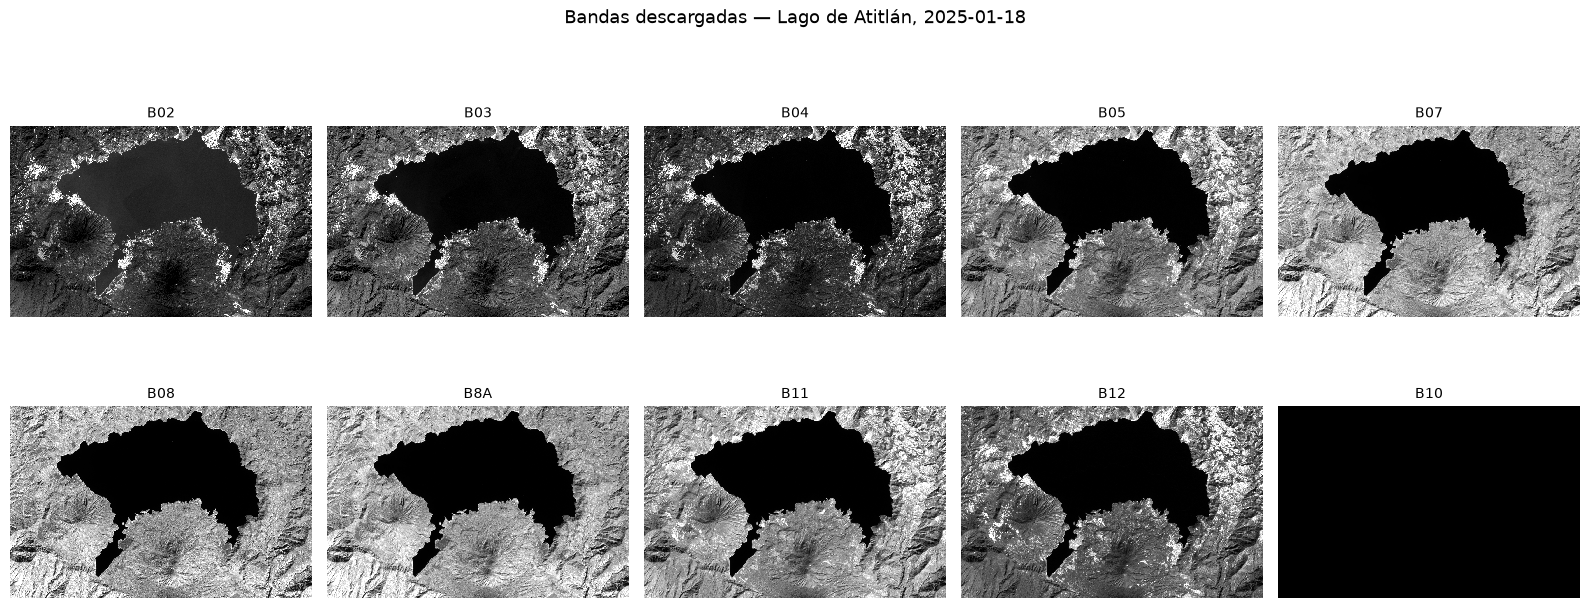

Rejilla: (876, 1380) | CRS: EPSG:32615


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from src import datos

escenas = datos.escenas_disponibles()
if escenas:
    lago, fecha = escenas[0]
    cubo, meta = datos.leer_cubo(lago, fecha)

    fig, ejes = plt.subplots(2, 5, figsize=(16, 7))
    for eje, nombre in zip(ejes.ravel(), config.BANDAS):
        banda = cubo[config.IDX_BANDA[nombre]]
        v = banda[banda > 0]
        lo, hi = np.percentile(v, (2, 98)) if v.size else (0, 1)
        eje.imshow(banda, cmap="gray", vmin=lo, vmax=max(hi, lo + 1),
                   interpolation="nearest")
        eje.set_title(nombre, fontsize=10)
        eje.axis("off")

    fig.suptitle(
        f"Bandas descargadas — {config.NOMBRE_LARGO[lago]}, {fecha}",
        fontsize=13,
    )
    fig.tight_layout()
    plt.show()

    print("Rejilla:", meta["shape"], "| CRS:", meta["crs"])
else:
    print("Sin escenas descargadas todavía.")

En las bandas visibles (B02, B03, B04) el lago se ve oscuro porque el agua absorbe casi toda
esa luz. En el infrarrojo (B08, B8A) y sobre todo en el infrarrojo de onda corta (B11, B12) el
agua se ve prácticamente negra, mientras la tierra alrededor se ilumina: ese contraste tan
fuerte es exactamente lo que permite dibujar el borde del lago de forma automática, y es lo
que aprovecha la máscara de agua del cuaderno siguiente.

---

**Siguiente:** `02_Indices.ipynb` — cálculo del índice de cianobacteria, NDVI y NDWI.